# EMG Windowing and Feature Extraction

**Objective:** Segment labeled sEMG recordings into fixed-duration windows and extract interpretable time-domain features for gesture classification.

**Dataset:** UCI EMG Data for Gestures  
**Sampling assumption:** 200 Hz  
**Window size:** 200 ms (40 samples)  
**Window overlap:** 50% (20-sample step)  
**Scope:** Educational and research demonstration only; not for clinical use.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import butter, filtfilt

In [2]:
from google.colab import files

uploaded = files.upload()
filename = next(iter(uploaded))

df = pd.read_csv(filename, sep="\t")

df.columns = [
    "time",
    "channel_1",
    "channel_2",
    "channel_3",
    "channel_4",
    "channel_5",
    "channel_6",
    "channel_7",
    "channel_8",
    "gesture"
]

df["gesture"] = pd.to_numeric(df["gesture"])
channels = [f"channel_{i}" for i in range(1, 9)]

print("Data shape:", df.shape)
print("Gesture classes:", sorted(df["gesture"].unique()))

Saving 1_raw_data_10-38_11.04.16.txt to 1_raw_data_10-38_11.04.16.txt
Data shape: (51078, 10)
Gesture classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


In [3]:
fs = 200
lowcut = 20
highcut = 80
filter_order = 4

def bandpass_filter(signal, fs, lowcut, highcut, order=4):
    nyquist = fs / 2
    b, a = butter(
        order,
        [lowcut / nyquist, highcut / nyquist],
        btype="bandpass"
    )
    return filtfilt(b, a, signal)

In [4]:
def root_mean_square(signal):
    return np.sqrt(np.mean(np.square(signal)))

def mean_absolute_value(signal):
    return np.mean(np.abs(signal))

def waveform_length(signal):
    return np.sum(np.abs(np.diff(signal)))

def zero_crossings(signal, threshold=1e-7):
    centered = signal - np.mean(signal)
    crossings = np.diff(np.signbit(centered))
    amplitude_change = np.abs(np.diff(centered)) >= threshold
    return np.sum(crossings & amplitude_change)

feature_functions = {
    "rms": root_mean_square,
    "mav": mean_absolute_value,
    "wl": waveform_length,
    "zc": zero_crossings
}

In [5]:
filtered_df = df.copy()

for channel in channels:
    filtered_df[channel] = bandpass_filter(
        filtered_df[channel].to_numpy(),
        fs=fs,
        lowcut=lowcut,
        highcut=highcut,
        order=filter_order
    )

print("All eight channels filtered.")

All eight channels filtered.


In [6]:
window_ms = 200
overlap = 0.50

window_size = int(fs * window_ms / 1000)
step_size = int(window_size * (1 - overlap))

print(f"Window size: {window_size} samples")
print(f"Step size: {step_size} samples")

feature_rows = []

for start in range(0, len(filtered_df) - window_size + 1, step_size):
    window = filtered_df.iloc[start:start + window_size]

    labels_in_window = window["gesture"].unique()

    if len(labels_in_window) != 1:
        continue

    gesture_label = labels_in_window[0]

    row = {
        "start_time": window["time"].iloc[0],
        "end_time": window["time"].iloc[-1],
        "gesture": gesture_label
    }

    for channel in channels:
        signal = window[channel].to_numpy()

        for feature_name, feature_function in feature_functions.items():
            row[f"{channel}_{feature_name}"] = feature_function(signal)

    feature_rows.append(row)

features_df = pd.DataFrame(feature_rows)

print("Feature table shape:", features_df.shape)
display(features_df.head())

Window size: 40 samples
Step size: 20 samples
Feature table shape: (2506, 35)


,start_time,end_time,gesture,channel_1_rms,channel_1_mav,channel_1_wl,channel_1_zc,channel_2_rms,channel_2_mav,channel_2_wl,...,channel_6_wl,channel_6_zc,channel_7_rms,channel_7_mav,channel_7_wl,channel_7_zc,channel_8_rms,channel_8_mav,channel_8_wl,channel_8_zc
0,1,55,0,0.000004,0.000003,0.000103,13,0.000007,0.000004,0.000224,...,0.000156,9,0.000002,9.948769e-07,0.000058,11,0.000004,0.000002,0.000086,10
1,24,75,0,0.000005,0.000004,0.000180,13,0.000008,0.000005,0.000284,...,0.000313,11,0.000003,1.952810e-06,0.000117,15,0.000005,0.000003,0.000167,17
2,56,98,0,0.000004,0.000002,0.000127,18,0.000006,0.000003,0.000117,...,0.000175,11,0.000002,1.206813e-06,0.000055,12,0.000005,0.000002,0.000141,15
3,76,119,0,0.000006,0.000003,0.000173,12,0.000004,0.000002,0.000128,...,0.000183,20,0.000002,1.385403e-06,0.000057,9,0.000003,0.000002,0.000096,12
4,99,140,0,0.000006,0.000004,0.000191,11,0.000004,0.000002,0.000122,...,0.000156,18,0.000003,2.150364e-06,0.000082,9,0.000004,0.000002,0.000126,10


Windows per gesture class:
gesture
0    1511
1     165
2     162
3     159
4     160
5     193
6     156
Name: count, dtype: int64


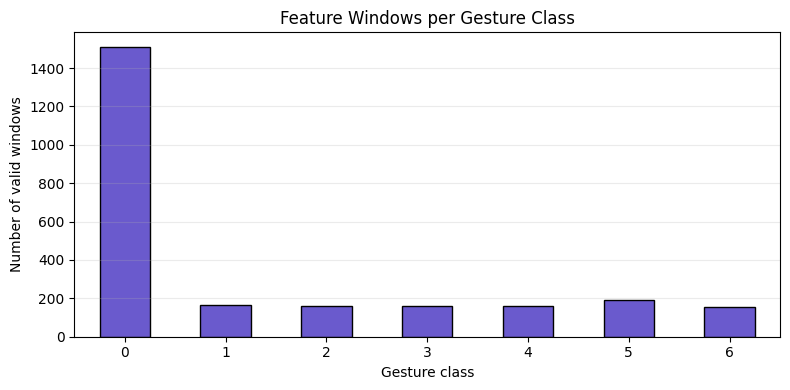

In [7]:
window_counts = features_df["gesture"].value_counts().sort_index()

print("Windows per gesture class:")
print(window_counts)

plt.figure(figsize=(8, 4))
window_counts.plot(kind="bar", color="slateblue", edgecolor="black")
plt.title("Feature Windows per Gesture Class")
plt.xlabel("Gesture class")
plt.ylabel("Number of valid windows")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

Windows retained per class: 156

Balanced window counts:
gesture
0    156
1    156
2    156
3    156
4    156
5    156
6    156
Name: count, dtype: int64


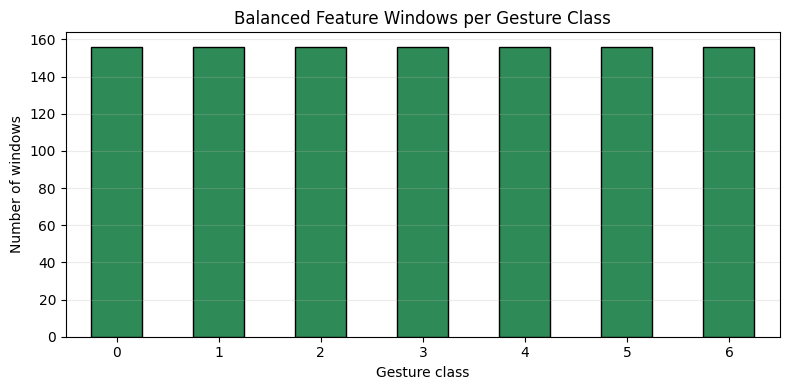

In [8]:
random_seed = 42

min_class_count = features_df["gesture"].value_counts().min()

balanced_features_df = (
    features_df
    .groupby("gesture", group_keys=False)
    .sample(n=min_class_count, random_state=random_seed)
    .sample(frac=1, random_state=random_seed)
    .reset_index(drop=True)
)

balanced_counts = balanced_features_df["gesture"].value_counts().sort_index()

print(f"Windows retained per class: {min_class_count}")
print("\nBalanced window counts:")
print(balanced_counts)

plt.figure(figsize=(8, 4))
balanced_counts.plot(kind="bar", color="seagreen", edgecolor="black")
plt.title("Balanced Feature Windows per Gesture Class")
plt.xlabel("Gesture class")
plt.ylabel("Number of windows")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

In [9]:
metadata_columns = ["start_time", "end_time", "gesture"]

X = balanced_features_df.drop(columns=metadata_columns)
y = balanced_features_df["gesture"]

print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)
print("\nFirst 10 feature names:")
print(X.columns[:10].tolist())

display(X.head())

Feature matrix shape: (1092, 32)
Label vector shape: (1092,)

First 10 feature names:
['channel_1_rms', 'channel_1_mav', 'channel_1_wl', 'channel_1_zc', 'channel_2_rms', 'channel_2_mav', 'channel_2_wl', 'channel_2_zc', 'channel_3_rms', 'channel_3_mav']


,channel_1_rms,channel_1_mav,channel_1_wl,channel_1_zc,channel_2_rms,channel_2_mav,channel_2_wl,channel_2_zc,channel_3_rms,channel_3_mav,...,channel_6_wl,channel_6_zc,channel_7_rms,channel_7_mav,channel_7_wl,channel_7_zc,channel_8_rms,channel_8_mav,channel_8_wl,channel_8_zc
0,0.000063,0.000046,0.001649,13,0.000012,0.000008,0.000289,12,0.000004,0.000003,...,0.000409,10,0.000038,0.000024,0.000872,12,0.000047,0.000034,0.001190,12
1,0.000004,0.000002,0.000120,17,0.000007,0.000003,0.000158,10,0.000011,0.000005,...,0.000107,11,0.000003,0.000001,0.000059,8,0.000005,0.000003,0.000101,11
2,0.000003,0.000002,0.000075,10,0.000004,0.000002,0.000083,13,0.000004,0.000002,...,0.000126,11,0.000004,0.000003,0.000104,11,0.000005,0.000003,0.000117,11
3,0.000020,0.000012,0.000393,11,0.000034,0.000024,0.000834,11,0.000071,0.000048,...,0.000293,9,0.000004,0.000003,0.000094,9,0.000006,0.000004,0.000157,11
4,0.000016,0.000011,0.000475,11,0.000014,0.000010,0.000438,12,0.000019,0.000012,...,0.001523,19,0.000017,0.000012,0.000484,15,0.000027,0.000018,0.000885,15


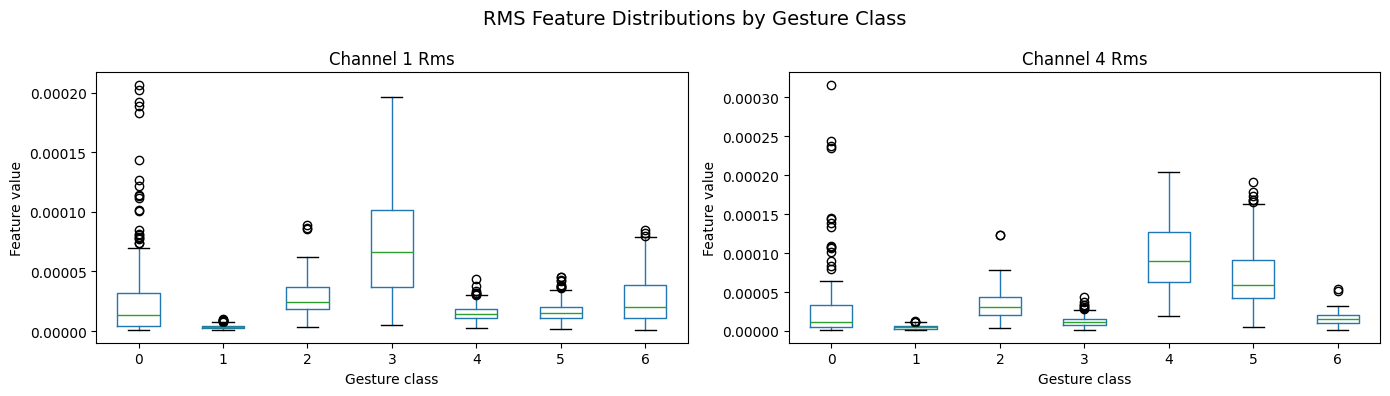

In [10]:
plot_features = ["channel_1_rms", "channel_4_rms"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, feature in zip(axes, plot_features):
    balanced_features_df.boxplot(
        column=feature,
        by="gesture",
        ax=ax,
        grid=False
    )
    ax.set_title(feature.replace("_", " ").title())
    ax.set_xlabel("Gesture class")
    ax.set_ylabel("Feature value")

plt.suptitle("RMS Feature Distributions by Gesture Class", fontsize=14)
plt.tight_layout()
plt.show()

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

lda_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LinearDiscriminantAnalysis())
])

lda_pipeline.fit(X_train, y_train)

y_pred = lda_pipeline.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")

print(f"Training windows: {len(X_train)}")
print(f"Test windows: {len(X_test)}")
print(f"Accuracy: {accuracy:.3f}")
print(f"Macro F1: {macro_f1:.3f}")

Training windows: 819
Test windows: 273
Accuracy: 0.681
Macro F1: 0.668


In [13]:
print(
    classification_report(
        y_test,
        y_pred,
        digits=3,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0      0.241     0.179     0.206        39
           1      0.672     1.000     0.804        39
           2      0.833     0.769     0.800        39
           3      0.711     0.692     0.701        39
           4      0.839     0.667     0.743        39
           5      0.719     0.590     0.648        39
           6      0.694     0.872     0.773        39

    accuracy                          0.681       273
   macro avg      0.673     0.681     0.668       273
weighted avg      0.673     0.681     0.668       273



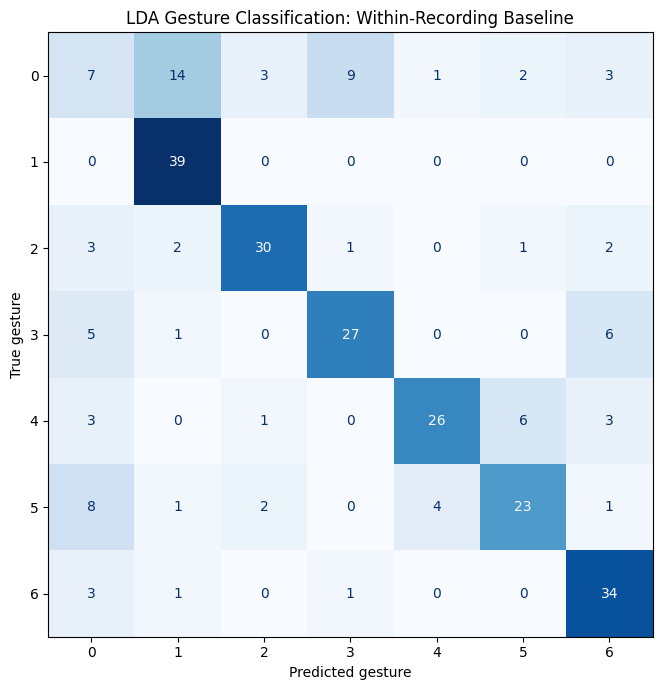

In [14]:
fig, ax = plt.subplots(figsize=(8, 7))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=sorted(y.unique()),
    cmap="Blues",
    colorbar=False,
    ax=ax
)

ax.set_title("LDA Gesture Classification: Within-Recording Baseline")
ax.set_xlabel("Predicted gesture")
ax.set_ylabel("True gesture")

plt.tight_layout()
plt.show()

## Baseline Classification Results

A standardized Linear Discriminant Analysis (LDA) classifier was trained on 32 time-domain features: RMS, mean absolute value, waveform length, and zero crossings across eight EMG channels.

Using a stratified 75/25 split of a class-balanced feature table, the within-recording baseline achieved:

- Accuracy: 0.681
- Macro F1: 0.668

Gesture classes 1 and 2 produced the strongest F1 scores (0.804 and 0.800), while the rest class (0) produced the weakest F1 score (0.206).

This evaluation is exploratory. The source windows overlap by 50%, so neighboring windows may contain highly similar signal content. The results should not be interpreted as independent-trial, cross-session, cross-user, real-time, or clinical performance.

In [15]:
results_summary = pd.DataFrame({
    "metric": ["accuracy", "macro_f1"],
    "value": [accuracy, macro_f1]
})

display(results_summary)

,metric,value
0,accuracy,0.681319
1,macro_f1,0.667825


In [16]:
is_new_trial = (
    (filtered_df["gesture"] != filtered_df["gesture"].shift())
    | (filtered_df.index.to_series().diff() != 1)
)

filtered_df["trial_id"] = is_new_trial.cumsum()

trial_summary = (
    filtered_df
    .groupby(["trial_id", "gesture"])
    .agg(
        start_time=("time", "min"),
        end_time=("time", "max"),
        samples=("time", "size")
    )
    .reset_index()
)

print("Continuous trials by gesture:")
display(trial_summary)

Continuous trials by gesture:


,trial_id,gesture,start_time,end_time,samples
0,1,0,1,964,901
1,2,1,968,2661,1633
2,3,0,2663,4566,1838
3,4,2,4568,6117,1505
4,5,0,6119,10587,4264
5,6,3,10593,12172,1394
6,7,0,12176,15245,2801
7,8,4,15246,17029,1581
8,9,0,17031,20269,3154
9,10,5,20271,22509,2177


In [17]:
feature_rows_with_trials = []

for start in range(0, len(filtered_df) - window_size + 1, step_size):
    window = filtered_df.iloc[start:start + window_size]

    if window["gesture"].nunique() != 1:
        continue

    if window["trial_id"].nunique() != 1:
        continue

    gesture_label = window["gesture"].iloc[0]

    if gesture_label == 0:
        continue

    row = {
        "start_time": window["time"].iloc[0],
        "end_time": window["time"].iloc[-1],
        "gesture": gesture_label,
        "trial_id": window["trial_id"].iloc[0]
    }

    for channel in channels:
        signal = window[channel].to_numpy()

        for feature_name, feature_function in feature_functions.items():
            row[f"{channel}_{feature_name}"] = feature_function(signal)

    feature_rows_with_trials.append(row)

trial_features_df = pd.DataFrame(feature_rows_with_trials)

print("Trial-aware feature table shape:", trial_features_df.shape)
print("\nWindows per gesture:")
print(trial_features_df["gesture"].value_counts().sort_index())

print("\nTrials per gesture:")
print(
    trial_features_df.groupby("gesture")["trial_id"]
    .nunique()
    .sort_index()
)

Trial-aware feature table shape: (995, 36)

Windows per gesture:
gesture
1    165
2    162
3    159
4    160
5    193
6    156
Name: count, dtype: int64

Trials per gesture:
gesture
1    2
2    2
3    2
4    2
5    2
6    2
Name: trial_id, dtype: int64


In [18]:
trial_counts = (
    trial_features_df
    .groupby(["gesture", "trial_id"])
    .size()
    .reset_index(name="windows")
    .sort_values(["gesture", "trial_id"])
)

display(trial_counts)

,gesture,trial_id,windows
0,1,2,79
1,1,14,86
2,2,4,73
3,2,16,89
4,3,6,67
5,3,18,92
6,4,8,77
7,4,20,83
8,5,10,107
9,5,22,86


In [19]:
trial_order = (
    trial_features_df
    .groupby(["gesture", "trial_id"])["start_time"]
    .min()
    .reset_index()
    .sort_values(["gesture", "start_time"])
)

train_trial_ids = (
    trial_order
    .groupby("gesture")
    .first()["trial_id"]
    .tolist()
)

test_trial_ids = (
    trial_order
    .groupby("gesture")
    .last()["trial_id"]
    .tolist()
)

train_df = trial_features_df[
    trial_features_df["trial_id"].isin(train_trial_ids)
].copy()

test_df = trial_features_df[
    trial_features_df["trial_id"].isin(test_trial_ids)
].copy()

print("Training trial IDs:", train_trial_ids)
print("Test trial IDs:", test_trial_ids)

print("\nTraining windows per gesture:")
print(train_df["gesture"].value_counts().sort_index())

print("\nTest windows per gesture:")
print(test_df["gesture"].value_counts().sort_index())

Training trial IDs: [2, 4, 6, 8, 10, 12]
Test trial IDs: [14, 16, 18, 20, 22, 24]

Training windows per gesture:
gesture
1     79
2     73
3     67
4     77
5    107
6     91
Name: count, dtype: int64

Test windows per gesture:
gesture
1    86
2    89
3    92
4    83
5    86
6    65
Name: count, dtype: int64


In [20]:
metadata_columns = ["start_time", "end_time", "gesture", "trial_id"]

X_train_trial = train_df.drop(columns=metadata_columns)
y_train_trial = train_df["gesture"]

X_test_trial = test_df.drop(columns=metadata_columns)
y_test_trial = test_df["gesture"]

print("Training feature matrix:", X_train_trial.shape)
print("Test feature matrix:", X_test_trial.shape)

Training feature matrix: (494, 32)
Test feature matrix: (501, 32)


In [21]:
trial_lda_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LinearDiscriminantAnalysis())
])

trial_lda_pipeline.fit(X_train_trial, y_train_trial)

y_pred_trial = trial_lda_pipeline.predict(X_test_trial)

trial_accuracy = accuracy_score(y_test_trial, y_pred_trial)
trial_macro_f1 = f1_score(y_test_trial, y_pred_trial, average="macro")

print(f"Trial-held-out accuracy: {trial_accuracy:.3f}")
print(f"Trial-held-out macro F1: {trial_macro_f1:.3f}")

print("\nClassification report:")
print(
    classification_report(
        y_test_trial,
        y_pred_trial,
        digits=3,
        zero_division=0
    )
)

Trial-held-out accuracy: 0.792
Trial-held-out macro F1: 0.785

Classification report:
              precision    recall  f1-score   support

           1      0.896     1.000     0.945        86
           2      0.866     0.652     0.744        89
           3      0.949     0.815     0.877        92
           4      0.736     0.807     0.770        83
           5      0.726     0.802     0.762        86
           6      0.575     0.646     0.609        65

    accuracy                          0.792       501
   macro avg      0.791     0.787     0.785       501
weighted avg      0.803     0.792     0.793       501



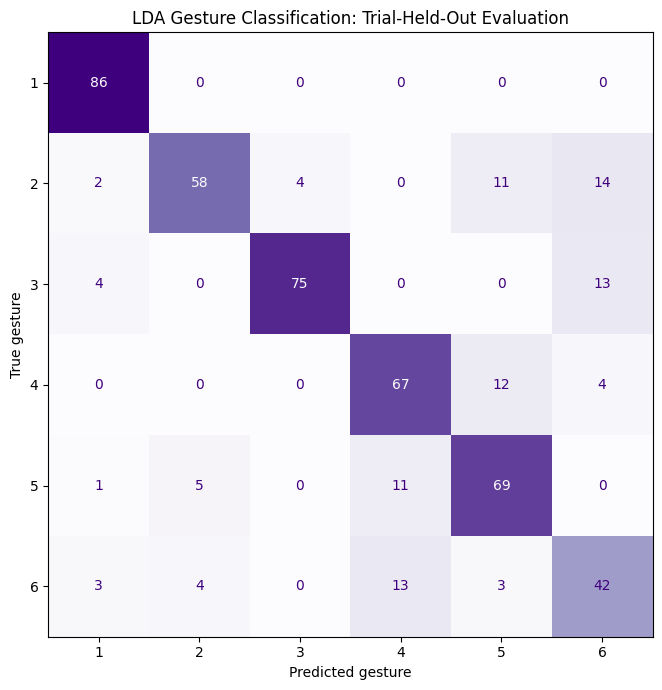

In [22]:
fig, ax = plt.subplots(figsize=(8, 7))

ConfusionMatrixDisplay.from_predictions(
    y_test_trial,
    y_pred_trial,
    display_labels=sorted(y_train_trial.unique()),
    cmap="Purples",
    colorbar=False,
    ax=ax
)

ax.set_title("LDA Gesture Classification: Trial-Held-Out Evaluation")
ax.set_xlabel("Predicted gesture")
ax.set_ylabel("True gesture")

plt.tight_layout()
plt.show()

## Trial-Held-Out Evaluation

To reduce leakage from overlapping windows, all windows from the first continuous trial of each active gesture were used for training and all windows from the second continuous trial were held out for testing.

The LDA classifier achieved:

- Trial-held-out accuracy: 0.792
- Trial-held-out macro F1: 0.785

The strongest gesture class was class 1 (F1 = 0.945). Class 6 was the most difficult active gesture to classify (F1 = 0.609).

This result represents cross-trial performance within one recording and for active gestures only. It does not establish cross-user, cross-session, real-time, or clinical performance.

In [23]:
from sklearn.inspection import permutation_importance

importance_result = permutation_importance(
    trial_lda_pipeline,
    X_test_trial,
    y_test_trial,
    scoring="f1_macro",
    n_repeats=30,
    random_state=42,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": X_test_trial.columns,
    "mean_importance": importance_result.importances_mean,
    "std_importance": importance_result.importances_std
}).sort_values("mean_importance", ascending=False)

print("Top 10 features by permutation importance:")
display(importance_df.head(10))

Top 10 features by permutation importance:


,feature,mean_importance,std_importance
16,channel_5_rms,0.339453,0.017217
28,channel_8_rms,0.277121,0.014650
8,channel_3_rms,0.269000,0.015880
0,channel_1_rms,0.214728,0.014817
20,channel_6_rms,0.208481,0.014622
1,channel_1_mav,0.192507,0.012662
6,channel_2_wl,0.128861,0.011509
12,channel_4_rms,0.128427,0.016913
25,channel_7_mav,0.117503,0.010274
24,channel_7_rms,0.110874,0.012494


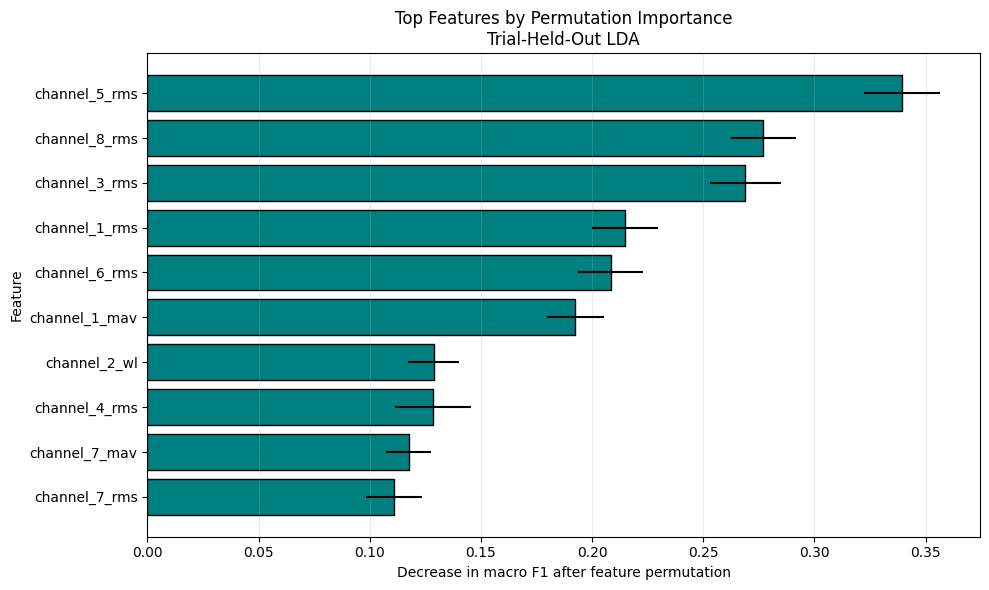

In [24]:
top_features = importance_df.head(10).sort_values("mean_importance")

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["feature"],
    top_features["mean_importance"],
    xerr=top_features["std_importance"],
    color="teal",
    edgecolor="black"
)

plt.title("Top Features by Permutation Importance\nTrial-Held-Out LDA")
plt.xlabel("Decrease in macro F1 after feature permutation")
plt.ylabel("Feature")
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

## Feature Importance

Permutation importance was calculated on the held-out trial using macro F1 as the scoring metric.

RMS features from channels 5, 8, 3, 1, and 6 produced the largest performance decreases when permuted. Channel 5 RMS was the strongest individual feature, reducing macro F1 by 0.339 on average when shuffled.

The importance pattern suggests that gesture discrimination in this recording relied primarily on channel-specific EMG amplitude, with additional contribution from mean absolute value and waveform length features.

These importance values are specific to this recording, preprocessing pipeline, LDA model, and trial-held-out split. They should not be interpreted as a general anatomical mapping or clinical finding.

In [25]:
importance_df["feature_family"] = importance_df["feature"].str.extract(
    r"_(rms|mav|wl|zc)$"
)

family_importance = (
    importance_df
    .groupby("feature_family", as_index=False)
    .agg(
        mean_importance=("mean_importance", "sum"),
        std_importance=("std_importance", "mean"),
        feature_count=("feature", "count")
    )
    .sort_values("mean_importance", ascending=False)
)

print("Permutation importance by feature family:")
display(family_importance)

Permutation importance by feature family:


,feature_family,mean_importance,std_importance,feature_count
1,rms,1.562532,0.014187,8
0,mav,0.656634,0.011517,8
2,wl,0.503737,0.011308,8
3,zc,0.048229,0.004782,8


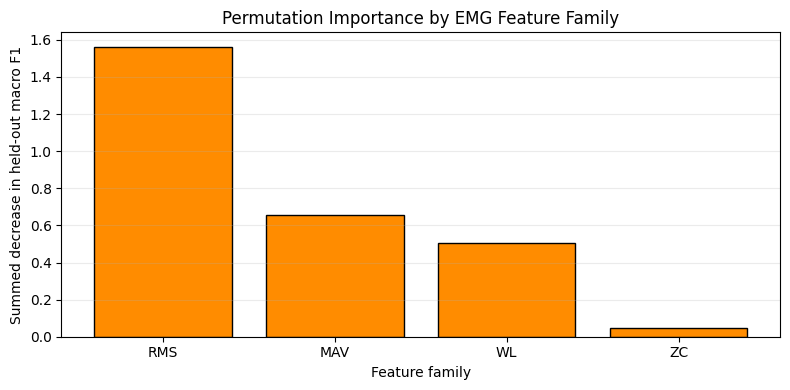

In [26]:
plt.figure(figsize=(8, 4))

plt.bar(
    family_importance["feature_family"].str.upper(),
    family_importance["mean_importance"],
    color="darkorange",
    edgecolor="black"
)

plt.title("Permutation Importance by EMG Feature Family")
plt.xlabel("Feature family")
plt.ylabel("Summed decrease in held-out macro F1")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## Feature-Family Importance

Permutation importance was aggregated across channels to compare time-domain feature families.

RMS produced the largest summed decrease in held-out macro F1 (1.563), followed by mean absolute value (0.657) and waveform length (0.504). Zero crossings produced the lowest summed importance (0.048).

For this cross-trial, single-recording experiment, gesture discrimination was driven primarily by amplitude-based EMG features. This result is specific to the selected recording, preprocessing parameters, feature set, LDA model, and evaluation split.